# 15. Thermal Interiors

A layer's temperature sets its viscosity, and so its tidal response, but the temperature itself follows from how much heat the layer makes and how fast it can lose it. TidalPy splits that into two model families attached to each `SolidLiquidLayer`: a cooling model (`cooling_x`) that maps a temperature drop onto a heat flux, and a radiogenics model (`radiogenics_x`) that maps a mass and a time onto a heating rate.

This notebook evaluates both families on their own, attaches them to the layers of the bundled Io, solves the equation of state with the temperature and heat flow carried through the structure, splits Io's tidal heating among its layers, and closes with a heat budget that says whether the interior would warm or cool.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, M_jup, seconds_per_myr
from TidalPy.cooling_x import make_cooling
from TidalPy.radiogenics_x import make_radiogenics, available_isotope_datasets, IsotopeRadiogenics
from TidalPy.structures_x.configs import build_world

# Io's orbit about Jupiter, used by the tidal sections.
A_IO = 4.217e8                         # semi-major axis [m]
E_IO = 0.0041                          # forced eccentricity
N_IO = np.sqrt(G * M_jup / A_IO**3)    # mean motion [rad s-1]; Io rotates synchronously
SURFACE_TEMPERATURE = 110.0            # Io's mean surface temperature [K]
LAYER_COLORS = {"core": "tab:gray", "mantle": "tab:brown", "asthenosphere": "tab:orange"}

## Cooling Models

`make_cooling` builds a cooling model by name: `off`, `conduction`, or `convection`. Each model's `calc_cooling` takes eight inputs: the temperature drop across the layer [K], the layer thickness [m], gravity [m s$^{-2}$], density [kg m$^{-3}$], viscosity [Pa s], thermal conductivity [W m$^{-1}$ K$^{-1}$], thermal diffusivity [m$^2$ s$^{-1}$], and thermal expansivity [K$^{-1}$]. It returns the heat flux [W m$^{-2}$], the thermal boundary-layer thickness [m], and the Rayleigh and Nusselt numbers.

The values below describe a silicate mantle about 900 km thick with a 1000 K temperature drop, close to Io's mantle.

In [2]:
# A silicate mantle: the same thermal constants as TidalPy's mantle_rock material defaults.
delta_temp   = 1000.0                             # [K]
thickness    = 9.1e5                              # [m]
gravity      = 1.5                                # [m s-2]
density      = 3300.0                             # [kg m-3]
conductivity = 3.75                               # [W m-1 K-1]
expansivity  = 5.2e-5                             # [K-1]
diffusivity  = conductivity / (density * 1200.0)  # [m2 s-1], with a heat capacity of 1200 J kg-1 K-1
viscosity    = 1.0e20                             # [Pa s]

cooling_models = {name: make_cooling(name) for name in ("off", "conduction", "convection")}
print(f"{'model':<11} {'flux [W/m2]':>12} {'boundary layer [km]':>20} {'Ra':>10} {'Nu':>7}")
for name, model in cooling_models.items():
    result = model.calc_cooling(
        delta_temp, thickness, gravity, density, viscosity, conductivity, diffusivity, expansivity)
    print(f"{model.model_name:<11} {result.cooling_flux:12.4f} {result.boundary_layer_thickness / 1e3:20.1f} "
          f"{result.rayleigh:10.3e} {result.nusselt:7.2f}")

model        flux [W/m2]  boundary layer [km]         Ra      Nu
off               0.0000                455.0  0.000e+00    1.00
conduction        0.0041                910.0  0.000e+00    1.00
convection        0.0507                 74.0  2.048e+06   12.30


The off model moves no heat. Conduction carries $k \Delta T / d$ across the whole layer. Convection thins the conducting region to a boundary layer of thickness $d / \mathrm{Nu}$, so it carries Nu times the conductive flux.

## Conduction to Convection Transition

The Rayleigh number $\mathrm{Ra} = \alpha \rho g \Delta T d^3 / (\eta \kappa)$ compares the buoyancy that drives a hot parcel upward with the viscous and diffusive losses that stop it. The convection model uses $\mathrm{Nu} = (\mathrm{Ra} / \mathrm{Ra}_\mathrm{crit})^{1/3}$ with $\mathrm{Ra}_\mathrm{crit} = 1100$ by default, and never lets the Nusselt number fall below 2. The sweep below raises the viscosity with everything else held fixed. `calc_cooling_vectorize_viscosity` evaluates the whole sweep in one call.

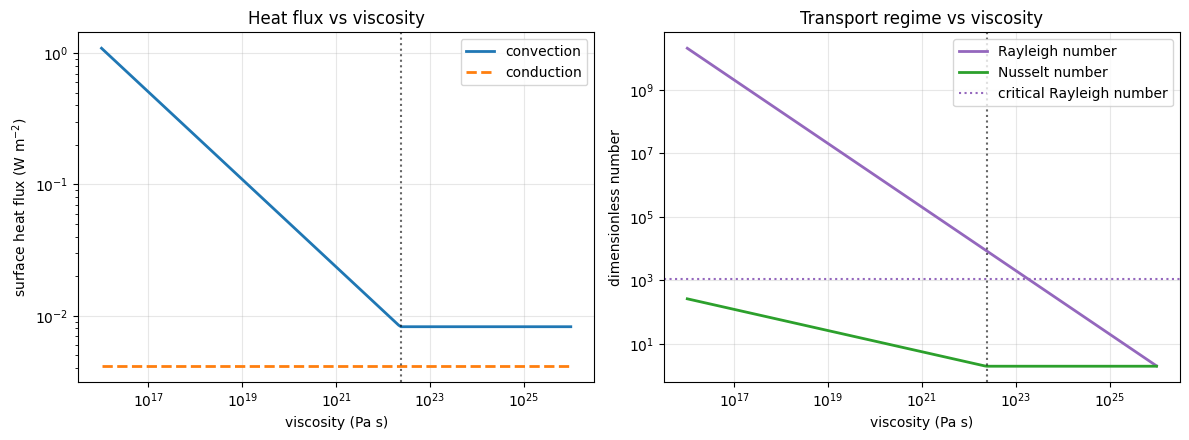

Ra falls to the critical value at a viscosity of 1.93e+23 Pa s
Nu reaches its floor of 2 at a viscosity of      2.41e+22 Pa s (dotted line)
flux ratio convection / conduction at 1e18 Pa s: 56.7


In [3]:
viscosities = np.logspace(16.0, 26.0, 200)   # [Pa s]

sweeps = {}
for name in ("conduction", "convection"):
    # Hold every input fixed except the viscosity.
    sweeps[name] = cooling_models[name].calc_cooling_vectorize_viscosity(
        delta_temp, thickness, gravity, density, viscosities, conductivity, diffusivity, expansivity)

convection = sweeps["convection"]
critical_viscosity = viscosities[np.argmin(np.abs(convection.rayleigh - 1100.0))]
floor_viscosity = viscosities[np.argmax(convection.nusselt <= 2.0)]

fig, (ax_flux, ax_numbers) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_flux.loglog(viscosities, convection.cooling_flux, lw=2, label="convection")
ax_flux.loglog(viscosities, sweeps["conduction"].cooling_flux, lw=2, ls="--", label="conduction")
ax_flux.set_ylabel("surface heat flux (W m$^{-2}$)")
ax_flux.set_title("Heat flux vs viscosity")

ax_numbers.loglog(viscosities, convection.rayleigh, lw=2, color="tab:purple", label="Rayleigh number")
ax_numbers.loglog(viscosities, convection.nusselt, lw=2, color="tab:green", label="Nusselt number")
ax_numbers.axhline(1100.0, color="tab:purple", ls=":", label="critical Rayleigh number")
ax_numbers.set_ylabel("dimensionless number")
ax_numbers.set_title("Transport regime vs viscosity")

for ax in (ax_flux, ax_numbers):
    ax.axvline(floor_viscosity, color="k", ls=":", alpha=0.6)
    ax.set_xlabel("viscosity (Pa s)")
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Ra falls to the critical value at a viscosity of {critical_viscosity:.2e} Pa s")
print(f"Nu reaches its floor of 2 at a viscosity of      {floor_viscosity:.2e} Pa s (dotted line)")
print(f"flux ratio convection / conduction at 1e18 Pa s: "
      f"{convection.cooling_flux[np.argmin(np.abs(viscosities - 1e18))] / sweeps['conduction'].cooling_flux[0]:.1f}")

At viscosities below the dotted line the convective flux falls as $\eta^{-1/3}$ and is between 2 and about 260 times the conductive flux. Above it the Nusselt floor holds the convective flux at twice the conductive value, even past the critical Rayleigh number where a real layer stops convecting. The convection model does not switch to conduction by itself: attach the `conduction` model to a layer whose Rayleigh number stays subcritical.

## Radiogenic Heating Models

`make_radiogenics` builds a radiogenics model by name: `off`, `isotope`, or `fixed`. `calc_heating(time, mass)` returns the heating [W] of a mass [kg] at a time [s]. With a mass of 1 kg it gives the specific heating rate [W kg$^{-1}$]. The isotope model sums the decay of a list of isotopes, and `available_isotope_datasets` lists the built-in literature sets. The fixed model applies one lumped rate with an optional single half-life.

Each model carries a reference time. The two present-day datasets quote their abundances at 4600 Myr after the formation of the solar system, so $t = 0$ is formation and $t = 4600$ Myr is today. The `llri_and_slri` set adds the short-lived isotopes and is referenced to formation instead.

built-in isotope datasets: ['modern_day_chondritic', 'llri', 'slri', 'llri_and_slri', 'bulk_silicate_earth']
modern_day_chondritic    at formation: 4.556e-11 W/kg   today: 5.173e-12 W/kg
bulk_silicate_earth      at formation: 2.487e-11 W/kg   today: 4.965e-12 W/kg
fixed, 2 Gyr half-life   at formation: 2.462e-11 W/kg   today: 5.000e-12 W/kg


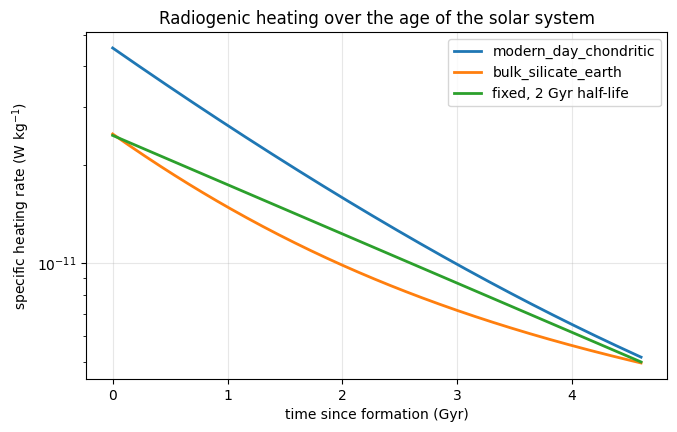

In [4]:
print("built-in isotope datasets:", available_isotope_datasets())

present_day = 4600.0 * seconds_per_myr   # [s] after formation
radiogenic_models = {
    "modern_day_chondritic": IsotopeRadiogenics.from_dataset("modern_day_chondritic"),
    "bulk_silicate_earth": make_radiogenics(
        "isotope",
        {"isotopes": "bulk_silicate_earth"}),                # the same kind of model, built by name
    "fixed, 2 Gyr half-life": make_radiogenics(
        "fixed",
        {"fixed_heat_production_w_kg": 5.0e-12,             # rate at the reference time [W kg-1]
         "average_half_life_s": 2000.0 * seconds_per_myr,   # one effective half-life [s]
         "ref_time_s": present_day}),                       # the rate is quoted for today
}

times = np.linspace(0.0, present_day, 300)   # [s] from formation to today
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, model in radiogenic_models.items():
    # Heating of one kilogram, so the result is the specific rate [W kg-1].
    specific_heating = model.calc_heating_vectorize_time(times, 1.0)
    ax.semilogy(times / seconds_per_myr / 1.0e3, specific_heating, lw=2, label=label)
    print(f"{label:<24} at formation: {specific_heating[0]:.3e} W/kg   today: {specific_heating[-1]:.3e} W/kg")
ax.set_xlabel("time since formation (Gyr)")
ax.set_ylabel("specific heating rate (W kg$^{-1}$)")
ax.set_title("Radiogenic heating over the age of the solar system")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The chondritic set starts higher because it carries more potassium, whose K40 decays with a 1.25 Gyr half-life. Uranium and thorium dominate the bulk silicate Earth set, so its rate falls more slowly.

## Cooling and Radiogenics on a World's Layers

The bundled Io has an iron core, a solid silicate mantle, and a 100 km thick, melt-weakened asthenosphere. Each layer receives the cooling and radiogenics models of its material type from the `[layers.<type>]` defaults in the TidalPy configuration: the mantle-rock layers convect and carry chondritic isotopes, and the iron core has both models off.

`set_cooling` and `set_radiogenics` replace a layer's model. The core's `off` cooling model makes it a perfect conductor, so here it is replaced with conduction, and the asthenosphere is given the bulk silicate Earth abundances. `use_heating` lets a layer's radiogenics model heat it during the structure solve.

In [5]:
io_thermal = build_world("io")

for layer in io_thermal:
    config = layer.get_config_dict()
    print(f"{layer.name:<14} cooling: {config['cooling']['model']:<11} "
          f"radiogenics: {config['radiogenics']['model']:<8} temperature: {layer.temperature:.0f} K")

io_thermal.core.set_cooling(make_cooling("conduction"))   # the core conducts instead of staying isothermal
io_thermal.asthenosphere.set_radiogenics(
    IsotopeRadiogenics.from_dataset("bulk_silicate_earth"))   # replaces the chondritic default
io_thermal.mantle.use_heating = True                          # radiogenic heat enters the thermal solve
io_thermal.asthenosphere.use_heating = True

print("core cooling is now:", io_thermal.core.get_config_dict()["cooling"]["model"])
asthenosphere_isotopes = io_thermal.asthenosphere.get_config_dict()["radiogenics"]
print("asthenosphere element concentrations are now:",
      dict(zip(asthenosphere_isotopes["isotope_names"], asthenosphere_isotopes["concentrations"])))

core           cooling: off         radiogenics: off      temperature: 1900 K
mantle         cooling: convection  radiogenics: isotope  temperature: 1600 K
asthenosphere  cooling: convection  radiogenics: isotope  temperature: 1600 K
core cooling is now: conduction
asthenosphere element concentrations are now: {'U238': 2.03e-08, 'U235': 2.03e-08, 'Th232': 7.95e-08, 'K40': 0.00024}


## Temperature and Heat Flow Profile

`solve_eos` integrates gravity, pressure, mass, and moment of inertia from the center to the surface. With `solve_temperature=True` it also integrates temperature and the outward heat flow $L(r)$ [W]. The solve treats each layer's `temperature` as an input and builds the profile around it according to the layer's cooling model:

- `off`: the layer is isothermal.
- `conduction`: the layer conducts, and its temperature applies at the mid-radius.
- `convection`: an adiabatic interior, $dT/dr = -\alpha g T / c_p$, between conducting boundary layers at the base and the top whose thickness comes from the Nusselt scaling. The layer's temperature applies at the base of the adiabat.

The layers form a chain of thermal resistances, and the heat flow through each interface follows from the temperature difference across it. `surface_temperature` is the temperature the outermost layer loses heat to. A heated layer adds $dL/dr = 4 \pi r^2 \epsilon \rho$, with $\epsilon$ its radiogenic rate [W kg$^{-1}$] at the solve's `time` (each model's own reference time when omitted, today for the chondritic set). Tidal heating is not a heat source in this solve.

The solve does not assume a steady state. The heat entering a layer need not equal the heat leaving it, and `layer_temperature_rate` [K s$^{-1}$] reports the resulting rate $M c_p \, dT/dt = L_\mathrm{in} - L_\mathrm{out} + H$. Viscosity and partial-melt models see the local temperature at every radius. Density sees it only for layers with `use_thermal_eos` set.

The bundled Io pins `solve_temperature = false` in its file, so the call passes it explicitly.

success: True   thermal passes: 3   converged: True


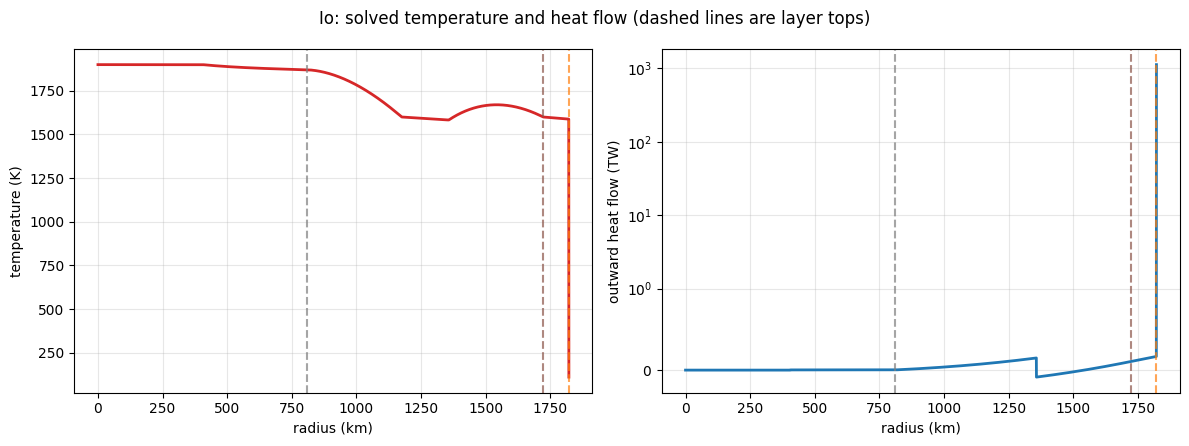

layer            T [K]  flow in [W]  flow out [W]  radiogenic [W]  dT/dt [K/Myr]
core              1900    0.000e+00     2.387e+09       0.000e+00          -0.01
mantle            1600    2.387e+09     1.049e+11       3.372e+11           0.09
asthenosphere     1600    1.049e+11     1.125e+15       6.280e+10       -2338.40


In [6]:
thermal = io_thermal.solve_eos(
    solve_temperature=True,                      # carry temperature and heat flow through the structure
    surface_temperature=SURFACE_TEMPERATURE)     # the outermost layer loses heat to 110 K
print(f"success: {thermal['success']}   thermal passes: {thermal['thermal_passes']}   "
      f"converged: {thermal['thermal_converged']}")

radii = np.linspace(0.0, io_thermal.radius, 4000)   # [m]
temperature = io_thermal.get_temperature(radii)      # [K], read from the solved profile
heat_flow = io_thermal.get_heat_flow(radii)          # [W], outward through each sphere

fig, (ax_temp, ax_flow) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_temp.plot(radii / 1e3, temperature, lw=2, color="tab:red")
ax_temp.set_ylabel("temperature (K)")
ax_flow.plot(radii / 1e3, heat_flow / 1e12, lw=2, color="tab:blue")
ax_flow.set_ylabel("outward heat flow (TW)")
ax_flow.set_yscale("symlog", linthresh=1.0)
for ax in (ax_temp, ax_flow):
    for layer in io_thermal:
        ax.axvline(layer.radius_outer / 1e3, color=LAYER_COLORS[layer.name], ls="--", alpha=0.7)
    ax.set_xlabel("radius (km)")
    ax.grid(alpha=0.3)
fig.suptitle("Io: solved temperature and heat flow (dashed lines are layer tops)")
fig.tight_layout()
plt.show()

print(f"{'layer':<14} {'T [K]':>7} {'flow in [W]':>12} {'flow out [W]':>13} {'radiogenic [W]':>15} "
      f"{'dT/dt [K/Myr]':>14}")
for i, layer in enumerate(io_thermal):
    print(f"{layer.name:<14} {thermal['layer_temperature'][i]:7.0f} {thermal['layer_heat_flow_in'][i]:12.3e} "
          f"{thermal['layer_heat_flow_out'][i]:13.3e} {thermal['layer_heating'][i]:15.3e} "
          f"{thermal['layer_temperature_rate'][i] * seconds_per_myr:14.2f}")

The core has no heat source, so its inner half carries no heat and stays at the 1900 K of its mid-radius, and its outer half conducts down to about 1870 K at the core-mantle boundary, passing a few $10^{9}$ W into the mantle. The mantle carries the same 1600 K as the asthenosphere above it, so its convection model sees no temperature contrast: the Rayleigh number is zero, the Nusselt number takes its floor of 2, and the boundary layers take as much of the layer as they are allowed. The mantle therefore conducts, and its own radiogenic heat raises a broad temperature maximum inside it, from which heat flows both down (the negative heat flow) and up into the asthenosphere. The asthenosphere's low viscosity gives a Nusselt number in the hundreds and a top boundary layer a few hundred meters thick, so it loses about $10^{15}$ W to the surface. The bundled Io has no conducting lithosphere, so this loss is larger than a model with a stagnant lid would give.

## Per-Layer Tidal Heating

`calc_tides` computes the world's total tidal heating, then gives each layer a share through its `tidal_scale_method`:

- `user_provided_scale`: the layer's `tidal_scale`. The bundled Io's values are the fractions of the total each layer dissipates in the depth-resolved 3D heating integral (notebook 9).
- `volume_fraction_scale`: the layer's share of the planet volume.
- `tidal_timescale_scale`: a log-Gaussian weight in the layer's Maxwell time $\tau = \eta / \mu$, equal to 1 where $\tau$ matches the forcing period $2 \pi / n$ and falling off with a width of `tidal_timescale_width_decades` (default 1). The weights are not normalized, so the layer shares need not sum to the total.

`tidal_timescale_scale` takes each layer's Maxwell time from the solved interior: the volume-weighted geometric mean of the post-melt $\eta / \mu$ over the layer, so the viscosity models the bundled Io's materials carry are seen. The tides use the fitted, fixed temperatures in the Io file, so this world is solved without the temperature profile.

total tidal heating: 9.3299e+13 W
method                           core         mantle  asthenosphere  sum / total
user_provided_scale         5.971e+08      3.814e+12      8.948e+13        1.000
volume_fraction_scale       8.204e+12      7.056e+13      1.454e+13        1.000
tidal_timescale_scale       2.126e+10      9.254e+11      2.448e+13        0.273


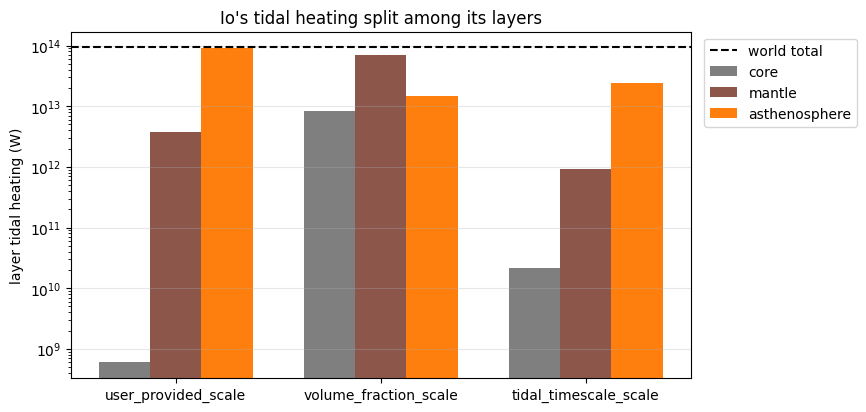

In [7]:
io_tides = build_world("io")
io_tides.solve_eos()   # the rheology tide model needs a solved interior

tidal_shares = {}
for method in ("user_provided_scale", "volume_fraction_scale", "tidal_timescale_scale"):
    for layer in io_tides:
        layer.tidal_scale_method = method
    io_tides.calc_tides(
        orbital_frequency=N_IO,   # [rad s-1]
        spin_frequency=N_IO,      # synchronous rotation
        eccentricity=E_IO,
        obliquity=0.0,
        semi_major_axis=A_IO,     # [m]
        host_mass=M_jup)          # [kg]
    tidal_shares[method] = np.array([io_tides.get_layer_tidal_heating(i) for i in range(len(io_tides))])

total_tidal = io_tides.get_tidal_heating()
print(f"total tidal heating: {total_tidal:.4e} W")
print(f"{'method':<22}" + "".join(f"{layer.name:>15}" for layer in io_tides) + f"{'sum / total':>13}")
for method, shares in tidal_shares.items():
    print(f"{method:<22}" + "".join(f"{share:15.3e}" for share in shares) + f"{shares.sum() / total_tidal:13.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_width = 0.25
positions = np.arange(len(tidal_shares))
for i, layer in enumerate(io_tides):
    ax.bar(positions + (i - 1) * bar_width, [shares[i] for shares in tidal_shares.values()],
           width=bar_width, color=LAYER_COLORS[layer.name], label=layer.name)
ax.axhline(total_tidal, color="k", ls="--", label="world total")
ax.set_xticks(positions, list(tidal_shares))
ax.set_yscale("log")
ax.set_ylabel("layer tidal heating (W)")
ax.set_title("Io's tidal heating split among its layers")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(alpha=0.3, axis="y")
plt.show()

The volume fraction places most of the heat in the mantle because it is the largest layer. The 3D-derived scales place 96 percent of it in the asthenosphere, where the Maxwell time is closest to the 1.77 day forcing period. The timescale weights rank the layers the same way but sum to about a quarter of the total.

## Heat Budget

Each layer gains its radiogenic and tidal heat plus the heat flowing in from below, and loses the heat flowing out through its top. Dividing the net power by $M c_p$ gives a warming or cooling rate. The tidal shares below are the 3D-derived user-provided scales, and the heat flows and radiogenic heating come from the thermal solve.

In [8]:
tidal_by_layer = tidal_shares["user_provided_scale"]   # [W]
print(f"{'layer':<14} {'radiogenic [W]':>15} {'tidal [W]':>11} {'net flow in [W]':>16} {'net [W]':>11} "
      f"{'dT/dt [K/Myr]':>14}")
for i, layer in enumerate(io_thermal):
    radiogenic = thermal["layer_heating"][i]
    net_flow_in = thermal["layer_heat_flow_in"][i] - thermal["layer_heat_flow_out"][i]
    net = radiogenic + tidal_by_layer[i] + net_flow_in
    warming_rate = net / (layer.mass * layer.heat_capacity) * seconds_per_myr   # [K Myr-1]
    print(f"{layer.name:<14} {radiogenic:15.3e} {tidal_by_layer[i]:11.3e} {net_flow_in:16.3e} {net:11.3e} "
          f"{warming_rate:14.1f}")

radiogenic_total = io_thermal.calc_internal_heating(present_day)   # [W], summed over the layers
heat_loss = io_thermal.get_heat_flow(io_thermal.radius)              # [W], leaving through the surface
net_world = radiogenic_total + total_tidal - heat_loss
print()
print(f"radiogenic heating : {radiogenic_total:.3e} W")
print(f"tidal heating      : {total_tidal:.3e} W")
print(f"surface heat loss  : {heat_loss:.3e} W")
print(f"net                : {net_world:.3e} W, so Io would {'warm' if net_world > 0.0 else 'cool'}")

layer           radiogenic [W]   tidal [W]  net flow in [W]     net [W]  dT/dt [K/Myr]
core                 0.000e+00   5.971e+08       -2.387e+09  -1.789e+09           -0.0
mantle               3.372e+11   3.814e+12       -1.025e+11   4.048e+12            1.6
asthenosphere        6.280e+10   8.948e+13       -1.125e+15  -1.035e+15        -2152.4

radiogenic heating : 4.000e+11 W
tidal heating      : 9.330e+13 W
surface heat loss  : 1.125e+15 W
net                : -1.031e+15 W, so Io would cool


The surface loss of the bundled Io, which has no conducting lithosphere, is about twelve times its radiogenic and tidal heating together, so the asthenosphere cools quickly. A stagnant lid, or a cooler asthenosphere, would bring the budget closer to balance.

## Recap

- `make_cooling` builds the `off`, `conduction`, and `convection` models. Convection sizes its boundary layers from the Rayleigh and Nusselt numbers, with a Nusselt floor of 2.
- `make_radiogenics` builds `isotope` models from a named dataset (`available_isotope_datasets()`) or explicit arrays, and `fixed` models with one decaying rate.
- Cooling and radiogenic models attach to layers. `solve_eos(solve_temperature=True, surface_temperature=...)` then carries temperature and heat flow through the structure. `get_temperature` and `get_heat_flow` read the profile, and the returned `layer_temperature_rate` gives each layer's warming or cooling rate.
- `tidal_scale_method` splits a world's tidal heating among its layers: user-provided shares, volume fractions, or a weight in each layer's solved Maxwell time.
- Radiogenic heating, tidal heating, and the heat flows combine into a heat budget for each layer.

Next: `16_earth_moon_sun` places worlds in a system where the star and the tidal host are different bodies, with both bodies of a pair dissipating.